# Data Processing for UNSW Gear Wear Dataset


## Mendeley Data


In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "UNSW_gear_wear"

files = data_folder.rglob("*.mat")

df_rows = []
for f in files:
    fname_parts = re.split("-|_", f.stem)
    print(fname_parts)

    run = fname_parts[0].lower()
    speed = int(fname_parts[1].replace("Hz", ""))
    load = int(fname_parts[2].replace("Nm", ""))

    fault = None
    time = fname_parts[3].split("h")
    time = float(f"{time[0]}.{time[1].replace('m', '')}")
    # print(time)

    if run == "dry":
        # FIXME: Go over the times
        if time < 0.24:
            fault = "healthy"
        elif time < 1.3:
            fault = "uncertain_wear"
        else:
            fault = "wear"
    elif run == "lubricated":
        if time < 3.5:
            fault = "healthy"
        elif time < 30:
            fault = "uncertain_pitting"
        else:
            fault = "pitting"

    mat = scipy.io.loadmat(f)
    # print(mat.keys())

    # TSA
    revolutions_per_TSA = 40
    step_size = 5
    sampling_rate = 100000  # Hz
    num_samples_per_revolution = int(sampling_rate / speed)
    pinion_teeth = 19

    tacho = mat["tacIN"].flatten()
    vib1 = mat["vib1"].flatten()
    vib2 = mat["vib2"].flatten()

    tacho = (tacho > 0.6) * 1  # clean (* 1 to ensure int, not boolean)
    crossing_idxs = np.where(np.diff(tacho) == 1)[0]
    print(
        "Num rotations in measurement:", len(crossing_idxs)
    )  # FIXME: check if looks correct
    angle = np.arange(len(crossing_idxs)) * 360
    interpolated_angle = np.interp(
        np.arange(len(tacho)), crossing_idxs, angle
    )  # ! Endings are incorrect because of extrapolation, but they get cut out

    # Signal OT
    ##

    # OT
    vib1_OT_signal = order_track_signal(
        vib1,
        np.arange(len(vib1)) / sampling_rate,
        interpolated_angle,
        num_samples_per_revolution=num_samples_per_revolution,
    )
    vib2_OT_signal = order_track_signal(
        vib2,
        np.arange(len(vib2)) / sampling_rate,
        interpolated_angle,
        num_samples_per_revolution=num_samples_per_revolution,
    )

    # Cut ends
    vib1_OT_signal = vib1_OT_signal[
        2 * num_samples_per_revolution : -2 * num_samples_per_revolution
    ]  # cut out the ends because of extrapolation
    vib2_OT_signal = vib2_OT_signal[
        2 * num_samples_per_revolution : -2 * num_samples_per_revolution
    ]  # cut out the ends because of extrapolation

    # TSA
    vib1_OT_TSA = signal_TSA(
        vib1_OT_signal, num_samples_per_revolution, revolutions_per_TSA, step_size
    )
    vib2_OT_TSA = signal_TSA(
        vib2_OT_signal, num_samples_per_revolution, revolutions_per_TSA, step_size
    )

    # FFT
    vib1_signal_OT_samples = np.abs(np.fft.rfft(vib1_OT_TSA, norm="forward", axis=1))[
        :, : 11 * pinion_teeth
    ]
    vib2_signal_OT_samples = np.abs(np.fft.rfft(vib2_OT_TSA, norm="forward", axis=1))[
        :, : 11 * pinion_teeth
    ]

    # Float32 conversion
    vib1_signal_OT_samples = vib1_signal_OT_samples.astype(np.float32)
    vib2_signal_OT_samples = vib2_signal_OT_samples.astype(np.float32)

    print("Sample shape:", vib1_signal_OT_samples.shape)
    # print(vib2_signal_OT_samples.shape)
    if vib1_signal_OT_samples.shape[0] != vib2_signal_OT_samples.shape[0]:
        raise ValueError("Different numbers of signal OT samples for vib1 and vib2.")

    # Explode rows
    for i in range(vib1_signal_OT_samples.shape[0]):
        df_rows.append(
            {
                "run": run,
                "speed": speed,
                "load": load,
                "fault": fault,
                "OT_method": "signal",
                "TSA_size": revolutions_per_TSA,
                "vib1": vib1_signal_OT_samples[i],
                "vib2": vib2_signal_OT_samples[i],
            }
        )

    # FFT OT
    ##

    # OT & FFT
    vib1_OT_FFT = order_track_FFT(
        vib1, None, interpolated_angle, num_orders=pinion_teeth * 11
    )
    vib2_OT_FFT = order_track_FFT(
        vib2, None, interpolated_angle, num_orders=pinion_teeth * 11
    )

    # TSA
    vib1_fft_OT_samples = FFT_TSA(vib1_OT_FFT, revolutions_per_TSA, step_size)
    vib2_fft_OT_samples = FFT_TSA(vib2_OT_FFT, revolutions_per_TSA, step_size)

    # Cut ends
    vib1_fft_OT_samples = vib1_fft_OT_samples.astype(np.float32)
    vib2_fft_OT_samples = vib2_fft_OT_samples.astype(np.float32)

    if vib1_fft_OT_samples.shape[0] != vib2_fft_OT_samples.shape[0]:
        raise ValueError("Different numbers of fft OT samples for vib1 and vib2.")

    # Explode rows
    for i in range(vib1_fft_OT_samples.shape[0]):
        df_rows.append(
            {
                "run": run,
                "speed": speed,
                "load": load,
                "fault": fault,
                "OT_method": "fft",
                "TSA_size": revolutions_per_TSA,
                "vib1": vib1_fft_OT_samples[i],
                "vib2": vib2_fft_OT_samples[i],
            }
        )

df = pd.DataFrame(df_rows)
df.head(3)

['Dry', '10Hz', '5Nm', '02h22m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '01h28m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '01h34m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '00h23m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '01h15m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '01h03m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '02h07m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '01h47m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '00h47m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Dry', '10Hz', '5Nm', '00h06m']
Num rotations in measurement: 110
Sample shape: (13, 209)
['Lubricated', '16Hz', '20Nm', '42h39m']
Num rotations in measurement: 174
Sample shape: (

,run,speed,load,fault,OT_method,TSA_size,vib1,vib2
0,dry,10,5,wear,signal,40,"[0.00013417465, 6.003178e-06, 2.2562373e-05, 1...","[0.00013417465, 6.003178e-06, 2.2562373e-05, 1..."
1,dry,10,5,wear,signal,40,"[0.00013871546, 2.6227735e-06, 2.6086667e-05, ...","[0.00013871546, 2.6227735e-06, 2.6086667e-05, ..."
2,dry,10,5,wear,signal,40,"[0.00013545506, 3.1836162e-06, 2.4600093e-05, ...","[0.00013545506, 3.1836162e-06, 2.4600093e-05, ..."


In [61]:
df.dtypes

run          object
speed         int64
load          int64
fault        object
OT_method    object
TSA_size      int64
vib1         object
vib2         object
dtype: object

In [62]:
# SAVING

df.to_feather(Path.cwd().parent.parent / "data" / "UNSW_wear.feather")

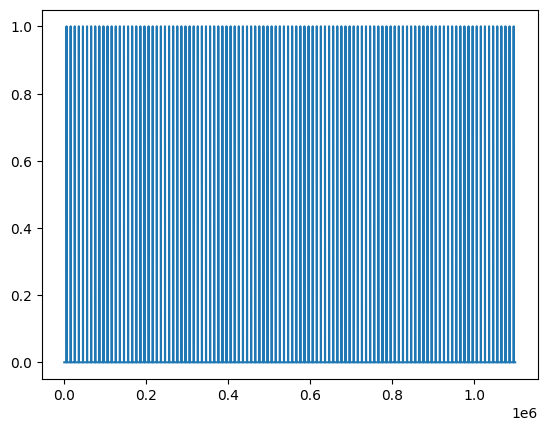

In [40]:
plt.plot(tacho > 0.6)